# NationalCSL-200 Skeleton-aware Transformer 孤立手語識別

**任務**：NationalCSL-200 signer-split 孤立詞識別  
**原始資料**：MediaPipe Holistic 2D 關鍵點序列，形狀 `(T, 225)`  
**輸入特徵**：relative / normalized landmarks + velocity，形狀 `(T, 450)`  
**模型**：skeleton-aware 三分支投影 + Transformer Encoder  

---
### 架構摘要
```
Raw landmarks (B, T, 225)
  └─ Relative / normalized preprocessing + velocity
       └─ Skeleton-aware pose / left / right branches
            └─ Transformer Encoder + masked mean pooling
                 └─ Classification Head → 196 classes
```
---
### 路徑說明
- 資料位於 Google Drive: `/content/drive/MyDrive/4016project/27261843/`
- `.npy` 關鍵點文件在 `landmarks/`，splits 在 `splits/`

## Cell 1 — 安裝依賴

In [1]:
# ── Cell 1: 安裝依賴 ──────────────────────────────────────────
# 僅需 torch（Colab 已內建），其餘為可選視覺化工具
!pip install -q tqdm matplotlib seaborn

## Cell 2 — 掛載 Drive & 設定路徑

In [2]:
# ── Cell 2: 掛載 Google Drive & 路徑設定 ────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
from pathlib import Path

# ─── 修改以下路徑以符合你的 Drive 結構 ───
PROJECT_ROOT  = Path('/content/drive/MyDrive/4016project/27261843')
SPLITS_DIR    = PROJECT_ROOT / 'splits'
LANDMARKS_DIR = PROJECT_ROOT / 'landmarks'
CKPT_DIR      = PROJECT_ROOT / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

# 把 project root 加入 sys.path，可直接 import build_dataset
sys.path.insert(0, str(PROJECT_ROOT))

# 驗證路徑
for p in [PROJECT_ROOT, SPLITS_DIR, LANDMARKS_DIR]:
    status = '✅' if p.exists() else '❌ 不存在'
    print(f"{status}  {p}")

npy_count = len(list(LANDMARKS_DIR.glob('*.npy')))
print(f"\n📊 找到 {npy_count} 個 .npy 檔案")

Mounted at /content/drive
✅  /content/drive/MyDrive/4016project/27261843
✅  /content/drive/MyDrive/4016project/27261843/splits
✅  /content/drive/MyDrive/4016project/27261843/landmarks

📊 找到 4000 個 .npy 檔案


## Cell 3 — Dataset & DataLoader

In [3]:
# Cell 3: Dataset & DataLoader
import csv
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

POSE_DIM = 33 * 3
LHAND_DIM = 21 * 3
RHAND_DIM = 21 * 3
RAW_FEATURE_DIM = POSE_DIM + LHAND_DIM + RHAND_DIM
POSE_FEATURE_DIM = POSE_DIM * 2
LHAND_FEATURE_DIM = LHAND_DIM * 2
RHAND_FEATURE_DIM = RHAND_DIM * 2
FEATURE_DIM = POSE_FEATURE_DIM + LHAND_FEATURE_DIM + RHAND_FEATURE_DIM

LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12
LEFT_WRIST = 15
RIGHT_WRIST = 16

def speed_perturb(seq, rate_range=(0.60, 1.40)):
    rate = np.random.uniform(*rate_range)
    T, D = seq.shape
    new_T = max(4, int(T / rate))
    idx = np.linspace(0, T - 1, new_T).astype(int)
    return seq[idx]

def temporal_crop(seq, min_ratio=0.72):
    T = seq.shape[0]
    if T <= 4:
        return seq
    keep = max(4, int(T * np.random.uniform(min_ratio, 1.0)))
    start = np.random.randint(0, T - keep + 1)
    return seq[start:start + keep]

def frame_drop(seq, drop_prob=0.18):
    T = seq.shape[0]
    if T <= 4:
        return seq
    mask = np.random.rand(T) > drop_prob
    if mask.sum() < 4:
        return seq
    return seq[mask]

def add_noise(seq, sigma=0.008):
    return seq + np.random.randn(*seq.shape).astype(np.float32) * sigma

def feature_mask(seq, mask_prob=0.08):
    dim_mask = (np.random.rand(seq.shape[1]) > mask_prob).astype(np.float32)
    return seq * dim_mask

def normalize_relative_landmarks(seq):
    seq = np.asarray(seq, dtype=np.float32)
    T = seq.shape[0]
    pose = seq[:, :POSE_DIM].reshape(T, 33, 3)
    lhand = seq[:, POSE_DIM:POSE_DIM + LHAND_DIM].reshape(T, 21, 3)
    rhand = seq[:, POSE_DIM + LHAND_DIM:].reshape(T, 21, 3)
    shoulder_center = 0.5 * (pose[:, LEFT_SHOULDER] + pose[:, RIGHT_SHOULDER])
    shoulder_scale = np.linalg.norm(pose[:, LEFT_SHOULDER] - pose[:, RIGHT_SHOULDER], axis=1, keepdims=True)
    shoulder_scale = np.clip(shoulder_scale, 1e-3, None)
    pose_rel = (pose - shoulder_center[:, None, :]) / shoulder_scale[:, None, :]
    lhand_rel = (lhand - pose[:, LEFT_WRIST:LEFT_WRIST + 1, :]) / shoulder_scale[:, None, :]
    rhand_rel = (rhand - pose[:, RIGHT_WRIST:RIGHT_WRIST + 1, :]) / shoulder_scale[:, None, :]
    feat = np.concatenate([pose_rel.reshape(T, -1), lhand_rel.reshape(T, -1), rhand_rel.reshape(T, -1)], axis=1)
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

def append_velocity_features(seq):
    velocity = np.diff(seq, axis=0, prepend=seq[:1])
    feat = np.concatenate([seq, velocity], axis=1)
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

class SignLanguageDataset(Dataset):
    def __init__(self, split_name='train', max_len=64, augment=False, splits_dir=None, landmarks_dir=None):
        self.max_len = max_len
        self.augment = augment
        self.splits_dir = Path(splits_dir) if splits_dir else SPLITS_DIR
        self.landmarks_dir = Path(landmarks_dir) if landmarks_dir else LANDMARKS_DIR
        self.label_map = self._build_label_map()
        self.num_classes = len(self.label_map)
        csv_path = self.splits_dir / f'splits_{split_name}.csv'
        if not csv_path.exists():
            raise FileNotFoundError(f'Missing {csv_path}')
        self.samples = []
        missing = 0
        with open(csv_path, encoding='utf-8') as f:
            for row in csv.DictReader(f):
                npy_path = self.landmarks_dir / f"{row['sample_id']}.npy"
                if npy_path.exists():
                    self.samples.append({'npy_path': str(npy_path), 'label': self.label_map[row['gloss_id']]})
                else:
                    missing += 1
        print(f'[{split_name.upper():5s}] loaded {len(self.samples)} samples, missing {missing}')

    def _build_label_map(self):
        meta_path = self.splits_dir / 'metadata.csv'
        glosses = set()
        with open(meta_path, encoding='utf-8') as f:
            for row in csv.DictReader(f):
                glosses.add(row['gloss_id'])
        return {g: i for i, g in enumerate(sorted(glosses))}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        raw_seq = np.load(item['npy_path']).astype(np.float32)
        raw_seq = np.nan_to_num(raw_seq, nan=0.0, posinf=0.0, neginf=0.0)
        seq = normalize_relative_landmarks(raw_seq)
        if self.augment:
            if np.random.rand() < 0.65:
                seq = speed_perturb(seq, rate_range=(0.60, 1.40))
            if np.random.rand() < 0.55:
                seq = temporal_crop(seq, min_ratio=0.72)
            if np.random.rand() < 0.35:
                seq = frame_drop(seq, drop_prob=0.18)
            if np.random.rand() < 0.65:
                seq = add_noise(seq, sigma=0.008)
        seq = append_velocity_features(seq)
        if self.augment and np.random.rand() < 0.45:
            seq = feature_mask(seq, mask_prob=0.08)
        if seq.shape[0] > self.max_len:
            seq = seq[:self.max_len]
        length = seq.shape[0]
        return torch.FloatTensor(seq), item['label'], length

def collate_fn(batch):
    batch.sort(key=lambda x: x[2], reverse=True)
    features = [x[0] for x in batch]
    labels = torch.LongTensor([x[1] for x in batch])
    lengths = torch.LongTensor([x[2] for x in batch])
    padded = pad_sequence(features, batch_first=True, padding_value=0.0)
    return padded, labels, lengths

BATCH_SIZE = 32
MAX_LEN = 64

train_ds = SignLanguageDataset('train', max_len=MAX_LEN, augment=True)
val_ds = SignLanguageDataset('val', max_len=MAX_LEN, augment=False)
test_ds = SignLanguageDataset('test', max_len=MAX_LEN, augment=False)

NUM_CLASSES = train_ds.num_classes
print(f'\nNUM_CLASSES = {NUM_CLASSES}')
print(f'FEATURE_DIM = {FEATURE_DIM}  (relative / normalized + velocity)')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)

sample_feat, sample_lbl, sample_len = next(iter(train_loader))
print('\nBatch check:')
print(f'  features: {sample_feat.shape}  (B, T_max, {FEATURE_DIM})')
print(f'  labels  : {sample_lbl.shape}')
print(f'  lengths : {sample_len[:5].tolist()} ...')


[TRAIN] loaded 3200 samples, missing 0
[VAL  ] loaded 400 samples, missing 0
[TEST ] loaded 400 samples, missing 0

NUM_CLASSES = 200
FEATURE_DIM = 450  (relative / normalized + velocity)

Batch check:
  features: torch.Size([32, 19, 450])  (B, T_max, 450)
  labels  : torch.Size([32])
  lengths : [19, 18, 18, 18, 17] ...


## Cell 4 — Skeleton-aware Transformer 模型定義

目前架構重點：
1. **Skeleton-aware 分支投影**：將 pose / left hand / right hand 分開編碼後再融合
2. **Positional Encoding**：為時序序列注入位置信息
3. **Transformer Encoder**：多層多頭自注意力建模全局時序依賴
4. **Dual pooling + 分類頭**：結合 masked mean pooling 與 attention pooling 提升關鍵幀聚合能力

In [4]:
# Cell 4: Skeleton-aware Transformer model
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class BranchProjector(nn.Module):
    def __init__(self, input_dim, branch_dim, dropout=0.2):
        super().__init__()
        hidden_dim = max(branch_dim * 2, 96)
        self.norm = nn.LayerNorm(input_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, branch_dim)
        )

    def forward(self, x):
        return self.net(self.norm(x))

class SkeletonAwareEmbedding(nn.Module):
    def __init__(self, d_model=288, dropout=0.2):
        super().__init__()
        if d_model % 3 != 0:
            raise ValueError('d_model must be divisible by 3 for pose/left/right branches')
        branch_dim = d_model // 3
        self.pose_proj = BranchProjector(POSE_FEATURE_DIM, branch_dim, dropout)
        self.lhand_proj = BranchProjector(LHAND_FEATURE_DIM, branch_dim, dropout)
        self.rhand_proj = BranchProjector(RHAND_FEATURE_DIM, branch_dim, dropout)
        self.fuse = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        pose = x[:, :, :POSE_FEATURE_DIM]
        lhand = x[:, :, POSE_FEATURE_DIM:POSE_FEATURE_DIM + LHAND_FEATURE_DIM]
        rhand = x[:, :, POSE_FEATURE_DIM + LHAND_FEATURE_DIM:]
        fused = torch.cat([self.pose_proj(pose), self.lhand_proj(lhand), self.rhand_proj(rhand)], dim=-1)
        return fused + self.fuse(fused)

class AttentionPooling(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        hidden_dim = max(d_model // 2, 96)
        self.score = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, pad_mask):
        scores = self.score(x).squeeze(-1)
        scores = scores.masked_fill(pad_mask, -1e4)
        attn = torch.softmax(scores, dim=1)
        return torch.sum(x * attn.unsqueeze(-1), dim=1)

class CSLTransformer(nn.Module):
    def __init__(self, input_dim=FEATURE_DIM, d_model=288, nhead=6, num_layers=4, dim_feedforward=576, dropout=0.3, num_classes=196, max_len=64):
        super().__init__()
        self.embedding = SkeletonAwareEmbedding(d_model=d_model, dropout=dropout * 0.7)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout * 0.5, max_len=max_len + 10)
        self.input_dropout = nn.Dropout(dropout * 0.35)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False)
        self.out_norm = nn.LayerNorm(d_model)
        self.attn_pool = AttentionPooling(d_model, dropout=dropout * 0.5)
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def _make_padding_mask(self, lengths, max_len):
        return torch.arange(max_len, device=lengths.device).unsqueeze(0) >= lengths.unsqueeze(1)

    def forward(self, x, lengths):
        x = self.embedding(x)
        x = self.pos_enc(x)
        x = self.input_dropout(x)
        T = x.size(1)
        pad_mask = self._make_padding_mask(lengths, T)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        mask_f = (~pad_mask).float().unsqueeze(-1)
        mean_x = (x * mask_f).sum(dim=1) / lengths.float().unsqueeze(1).clamp(min=1.0)
        attn_x = self.attn_pool(x, pad_mask)
        mean_x = self.out_norm(mean_x)
        attn_x = self.out_norm(attn_x)
        pooled = torch.cat([mean_x, attn_x], dim=1)
        logits = self.classifier(pooled)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## Cell 5 — 訓練配置（優化器 / 調度器 / 損失函數）

In [5]:
# Cell 5: Training config
import torch.optim as optim

D_MODEL = 384
NHEAD = 6
NUM_LAYERS = 4
DIM_FEEDFORWARD = 768
DROPOUT = 0.35

model = CSLTransformer(
    input_dim=FEATURE_DIM,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN
).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel params: {total_params:,}')
print(f'Trainable   : {train_params:,}')

with torch.no_grad():
    dummy_x = torch.randn(4, 30, FEATURE_DIM).to(device)
    dummy_len = torch.tensor([30, 25, 20, 15]).to(device)
    dummy_out = model(dummy_x, dummy_len)
    print(f'\nForward check: {dummy_out.shape}')

LR = 4.5e-4
WEIGHT_DECAY = 2e-3
MAX_EPOCHS = 180
WARMUP_EPOCHS = 12
PATIENCE = 35
LABEL_SMOOTH = 0.15
MIXUP_ALPHA = 0.4
MIXUP_PROB = 0.65
GRAD_CLIP = 1.0
MIN_LR_SCALE = 0.10

class LabelSmoothingCE(nn.Module):
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        log_prob = F.log_softmax(logits, dim=-1)
        if targets.dim() == 1:
            soft_targets = F.one_hot(targets, self.num_classes).float()
        else:
            soft_targets = targets.float()
        soft_targets = soft_targets * (1.0 - self.smoothing) + self.smoothing / self.num_classes
        return -(soft_targets * log_prob).sum(dim=-1).mean()


def mixup_batch(features, labels, num_classes, alpha=MIXUP_ALPHA, prob=MIXUP_PROB):
    soft_labels = F.one_hot(labels, num_classes).float()
    if alpha <= 0 or np.random.rand() >= prob:
        return features, soft_labels

    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1.0 - lam)
    rand_idx = torch.randperm(features.size(0), device=features.device)
    mixed_features = lam * features + (1.0 - lam) * features[rand_idx]
    mixed_labels = lam * soft_labels + (1.0 - lam) * soft_labels[rand_idx]
    return mixed_features, mixed_labels


criterion = LabelSmoothingCE(NUM_CLASSES, smoothing=LABEL_SMOOTH).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def get_lr(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, MAX_EPOCHS - WARMUP_EPOCHS)
    cosine = 0.5 * (1 + math.cos(math.pi * progress))
    return MIN_LR_SCALE + (1.0 - MIN_LR_SCALE) * cosine

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)

print(f'Model config : d_model={D_MODEL}  heads={NHEAD}  layers={NUM_LAYERS}  ffn={DIM_FEEDFORWARD}')
print(f'Optimizer    : AdamW  lr={LR}  weight_decay={WEIGHT_DECAY}')
print(f'Scheduler    : Warmup({WARMUP_EPOCHS}) + Cosine floor={MIN_LR_SCALE:.2f}')
print(f'Loss         : LabelSmoothingCE  smoothing={LABEL_SMOOTH}')
print(f'MixUp        : prob={MIXUP_PROB}  alpha={MIXUP_ALPHA}')
print(f'Max epochs   : {MAX_EPOCHS}  patience={PATIENCE}')



Model params: 5,547,597
Trainable   : 5,547,597

Forward check: torch.Size([4, 200])
Model config : d_model=384  heads=6  layers=4  ffn=768
Optimizer    : AdamW  lr=0.00045  weight_decay=0.002
Scheduler    : Warmup(12) + Cosine floor=0.10
Loss         : LabelSmoothingCE  smoothing=0.15
MixUp        : prob=0.65  alpha=0.4
Max epochs   : 180  patience=35


## Cell 6 — 訓練 & 驗證循環

In [6]:
# Cell 6: Training and evaluation loop
import time
from tqdm.notebook import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for features, labels, lengths in loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)

        mixed_features, soft_labels = mixup_batch(features, labels, NUM_CLASSES)

        optimizer.zero_grad(set_to_none=True)
        logits = model(mixed_features, lengths)
        loss = criterion(logits, soft_labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        hard_labels = soft_labels.argmax(dim=1)
        correct += (logits.argmax(1) == hard_labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, top_k=(1, 5)):
    model.eval()
    total_loss = 0.0
    correct_k = {k: 0 for k in top_k}
    total = 0

    for features, labels, lengths in loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)

        logits = model(features, lengths)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)

        for k in top_k:
            _, topk_pred = logits.topk(min(k, logits.size(1)), dim=1)
            correct_k[k] += (topk_pred == labels.unsqueeze(1)).any(dim=1).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    acc_dict = {k: correct_k[k] / total for k in top_k}
    return avg_loss, acc_dict


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_top1': [], 'val_top5': []}

best_val_top1 = 0.0
best_ckpt_path = str(CKPT_DIR / 'best_model.pth')
no_improve = 0

print(f'Start training for {MAX_EPOCHS} epochs, classes = {NUM_CLASSES}\n')
header = '{:>6} | {:>8} | {:>10} | {:>9} | {:>9} | {:>8} | {:>8} | {:>7}'.format('Epoch', 'LR', 'TrainLoss', 'TrainAcc', 'ValLoss', 'ValTop1', 'ValTop5', 'Time')
print(header)
print('-' * len(header))

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, top_k=(1, 5))
    val_top1 = val_acc[1]
    val_top5 = val_acc[5]

    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_top1'].append(val_top1)
    history['val_top5'].append(val_top5)

    elapsed = time.time() - t0
    marker = ' <- best' if val_top1 > best_val_top1 else ''

    print(f'{epoch:>6} | {cur_lr:>8.2e} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {val_loss:>9.4f} | {val_top1:>7.2%} | {val_top5:>7.2%} | {elapsed:>5.1f}s{marker}')

    if val_top1 > best_val_top1:
        best_val_top1 = val_top1
        no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'val_top1': val_top1,
            'val_top5': val_top5,
            'num_classes': NUM_CLASSES,
            'label_map': train_ds.label_map,
            'config': {
                'feature_dim': FEATURE_DIM,
                'd_model': D_MODEL,
                'nhead': NHEAD,
                'num_layers': NUM_LAYERS,
                'dim_feedforward': DIM_FEEDFORWARD,
                'dropout': DROPOUT,
                'max_len': MAX_LEN,
                'weight_decay': WEIGHT_DECAY,
                'label_smooth': LABEL_SMOOTH,
                'mixup_prob': MIXUP_PROB,
                'mixup_alpha': MIXUP_ALPHA,
                'min_lr_scale': MIN_LR_SCALE,
                'pooling': 'mean_plus_attention',
                'feature_mode': 'relative_normalized_plus_velocity'
            }
        }, best_ckpt_path)
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} ({PATIENCE} rounds without improvement)')
        break

print(f'\nTraining complete. Best val Top-1 = {best_val_top1:.2%}')
print(f'Best model saved to: {best_ckpt_path}')


Start training for 180 epochs, classes = 200

 Epoch |       LR |  TrainLoss |  TrainAcc |   ValLoss |  ValTop1 |  ValTop5 |    Time
--------------------------------------------------------------------------------------
     1 | 7.50e-05 |     5.3226 |    0.75% |    5.2991 |   0.50% |   2.75% |  36.6s <- best
     2 | 1.12e-04 |     5.3179 |    0.25% |    5.2986 |   1.00% |   2.50% |   6.6s <- best
     3 | 1.50e-04 |     5.3146 |    0.38% |    5.3000 |   0.50% |   2.50% |   6.9s
     4 | 1.88e-04 |     5.3116 |    0.41% |    5.3059 |   0.50% |   2.50% |   8.0s
     5 | 2.25e-04 |     5.3090 |    0.47% |    5.2943 |   0.25% |   2.00% |   6.4s
     6 | 2.62e-04 |     5.2998 |    0.50% |    5.2855 |   1.50% |   4.00% |   6.8s <- best
     7 | 3.00e-04 |     5.2964 |    0.69% |    5.2907 |   0.50% |   4.00% |   6.4s
     8 | 3.38e-04 |     5.2711 |    0.81% |    5.1611 |   0.50% |   6.00% |   7.9s
     9 | 3.75e-04 |     5.1655 |    0.88% |    4.9942 |   1.25% |   6.25% |   6.2s
    10 | 

## Cell 7 — 訓練過程可視化

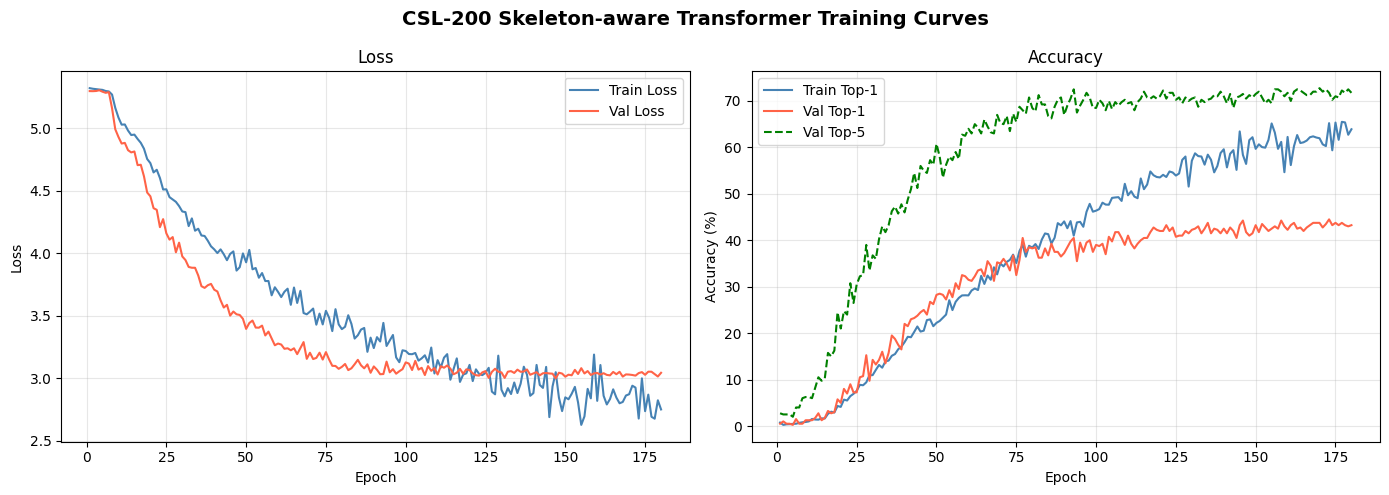

圖表已保存至 /content/drive/MyDrive/4016project/27261843/checkpoints/training_curves.png


In [7]:
# ── Cell 7: 訓練曲線可視化 ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CSL-200 Skeleton-aware Transformer Training Curves', fontsize=14, fontweight='bold')

# Loss 曲線
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train Loss', color='steelblue')
ax.plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy 曲線
ax = axes[1]
ax.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train Top-1', color='steelblue')
ax.plot(epochs_ran, [a*100 for a in history['val_top1']],  label='Val Top-1',   color='tomato')
ax.plot(epochs_ran, [a*100 for a in history['val_top5']],  label='Val Top-5',   color='green', linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(str(CKPT_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'圖表已保存至 {CKPT_DIR / "training_curves.png"}')

## Cell 8 — 最終測試集評估

In [8]:
# ── Cell 8: 最終測試集評估 ───────────────────────────────────────
print('載入最佳 checkpoint 進行測試集評估...')

# 載入最佳模型
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
print(f'  已載入 Epoch {ckpt["epoch"]} 的 checkpoint（Val Top-1 = {ckpt["val_top1"]:.2%}）')

# 測試集評估
test_loss, test_acc = evaluate(model, test_loader, criterion, device, top_k=(1, 5))
test_top1 = test_acc[1]
test_top5 = test_acc[5]

print(f'\n{'='*50}')
print(f'  最終測試集結果')
print(f'{'='*50}')
print(f'  Test Loss    : {test_loss:.4f}')
print(f'  Test Top-1   : {test_top1:.2%}')
print(f'  Test Top-5   : {test_top5:.2%}')
print(f'  Val/Test Gap : {test_top1 - best_val_top1:+.2%}')
print(f'{'='*50}')

gap = best_val_top1 - test_top1
if gap <= 0.02:
    print(f'\n  ✅ 測試表現與驗證集接近，泛化相對穩定')
else:
    print(f'\n  ⚠️  測試較驗證下降 {gap:.2%}，仍有 signer 泛化落差')

載入最佳 checkpoint 進行測試集評估...
  已載入 Epoch 173 的 checkpoint（Val Top-1 = 44.50%）

  最終測試集結果
  Test Loss    : 3.1244
  Test Top-1   : 40.50%
  Test Top-5   : 70.75%
  Val/Test Gap : -4.00%

  ⚠️  測試較驗證下降 4.00%，仍有 signer 泛化落差


## Cell 9 — 混淆矩陣（Top-20 易混淆類別）

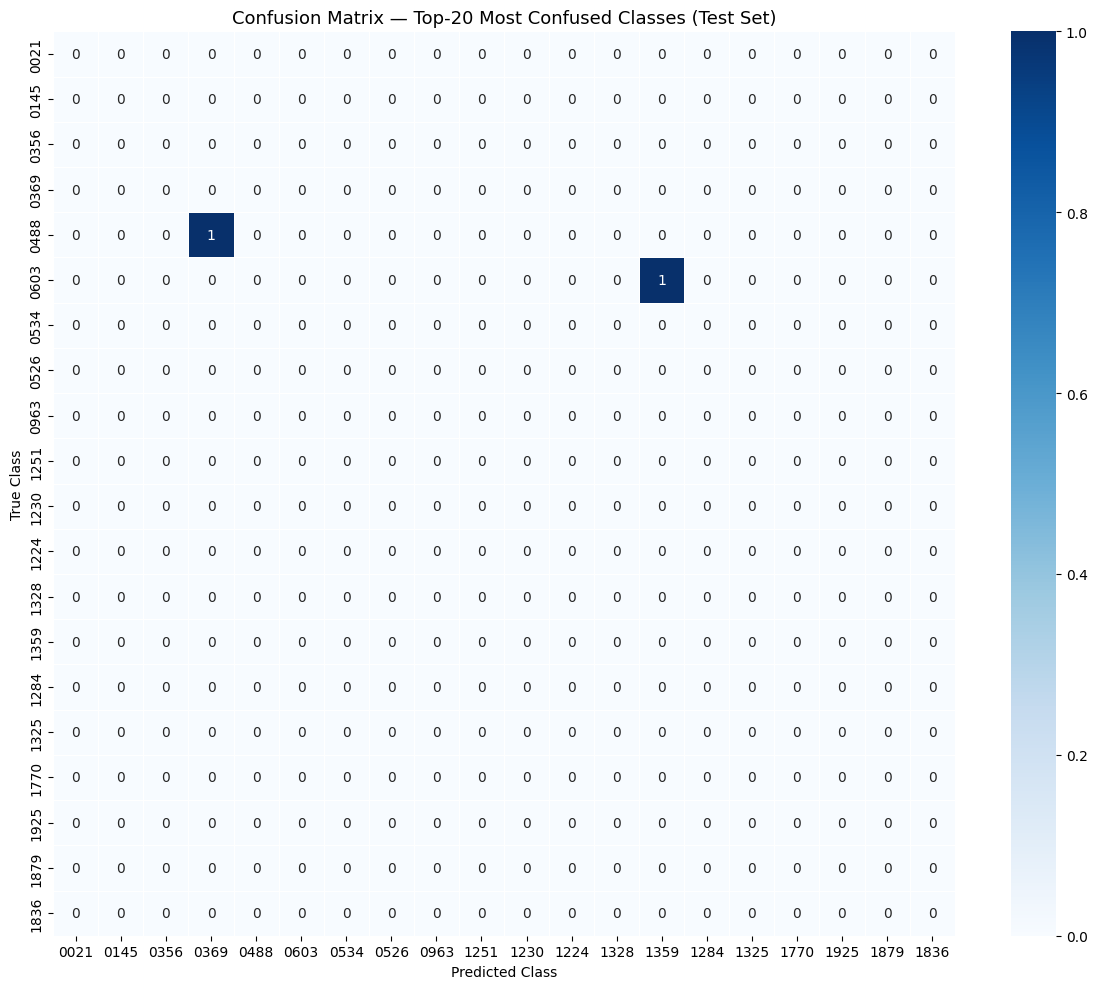


最低準確率的 20 個手語詞：
Gloss ID Accuracy
    0021     0.0%
    0145     0.0%
    0356     0.0%
    0369     0.0%
    0488     0.0%
    0603     0.0%
    0534     0.0%
    0526     0.0%
    0963     0.0%
    1251     0.0%
    1230     0.0%
    1224     0.0%
    1328     0.0%
    1359     0.0%
    1284     0.0%
    1325     0.0%
    1770     0.0%
    1925     0.0%
    1879     0.0%
    1836     0.0%


In [9]:
# ── Cell 9: 混淆矩陣分析（Top-20 最常出錯的類別）─────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for features, labels, lengths in test_loader:
        features = features.to(device)
        lengths  = lengths.to(device)
        logits   = model(features, lengths)
        preds    = logits.argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# 反轉 label_map（整數 → gloss_id）
inv_map = {v: k for k, v in train_ds.label_map.items()}

# 計算每個類別的準確率，找出最低的 20 個
from sklearn.metrics import classification_report
import pandas as pd

cm = confusion_matrix(all_labels, all_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_idx = np.argsort(per_class_acc)[:20]         # 最低 20 個類別

# 繪製子混淆矩陣
sub_labels = list(worst_idx)
sub_cm = cm[np.ix_(sub_labels, sub_labels)]
sub_names = [inv_map[i] for i in sub_labels]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sub_cm, xticklabels=sub_names, yticklabels=sub_names,
            annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix — Top-20 Most Confused Classes (Test Set)', fontsize=13)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.tight_layout()
fig.savefig(str(CKPT_DIR / 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# 打印最低準確率類別
print('\n最低準確率的 20 個手語詞：')
worst_df = pd.DataFrame({
    'Gloss ID': [inv_map[i] for i in worst_idx],
    'Accuracy': [f"{per_class_acc[i]:.1%}" for i in worst_idx]
})
print(worst_df.to_string(index=False))

## Cell 10 — 超參數消融實驗（可選）

測試不同配置對準確率的影響，驗證論文中消融結論。

In [10]:
# ── Cell 10: 消融實驗 ────────────────────────────────────────────
# 此 Cell 需要完整執行 Cell 3-6 後才能運行
# 設置 RUN_ABLATION=True 才執行（避免意外重訓）
RUN_ABLATION = False

if not RUN_ABLATION:
    print('消融實驗已跳過。設置 RUN_ABLATION=True 後重新執行此 Cell。')
else:
    ABLATION_EPOCHS = 60      # 消融用較少輪數
    ABLATION_PATIENCE = 15

    ablation_configs = [
        # 名稱, num_layers, d_model, nhead, dim_feedforward
        ('Skeleton-aware L=2 d=192',           2, 192, 6, 384),
        ('Skeleton-aware L=4 d=288',           4, 288, 6, 576),
        ('Skeleton-aware L=4 d=384 (current)', 4, 384, 6, 768),
        ('Skeleton-aware L=6 d=384',           6, 384, 6, 768),
    ]

    ablation_results = []

    for name, num_layers, d_model, nhead, dim_feedforward in ablation_configs:
        print(f'\n─── 測試配置：{name} ───')

        m = CSLTransformer(
            input_dim=FEATURE_DIM,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=DROPOUT,
            num_classes=NUM_CLASSES,
            max_len=MAX_LEN
        ).to(device)

        opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=1e-3)
        sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ABLATION_EPOCHS)
        crit = LabelSmoothingCE(NUM_CLASSES, 0.1).to(device)

        best_v1 = 0.0
        no_imp  = 0
        for ep in range(1, ABLATION_EPOCHS + 1):
            train_one_epoch(m, train_loader, opt, crit, device)
            _, vacc = evaluate(m, val_loader, crit, device)
            v1 = vacc[1]
            sch.step()
            if v1 > best_v1:
                best_v1 = v1; no_imp = 0
            else:
                no_imp += 1
            if no_imp >= ABLATION_PATIENCE:
                break
            if ep % 10 == 0:
                print(f'  Ep {ep:3d}  Val Top-1 = {v1:.2%}  Best = {best_v1:.2%}')

        # 測試集
        _, tacc = evaluate(m, test_loader, crit, device)
        ablation_results.append({'Config': name, 'Val Top-1': f'{best_v1:.2%}',
                                  'Test Top-1': f'{tacc[1]:.2%}', 'Test Top-5': f'{tacc[5]:.2%}'})
        del m
        torch.cuda.empty_cache()

    # 打印消融結果表格
    print('\n消融實驗結果匯總：')
    abl_df = pd.DataFrame(ablation_results)
    print(abl_df.to_string(index=False))

消融實驗已跳過。設置 RUN_ABLATION=True 後重新執行此 Cell。


## Cell 11 — 推理示例（單樣本預測）

In [11]:
# ── Cell 11: 推理示例 ────────────────────────────────────────────
# 從測試集中取幾個樣本，展示 Top-5 預測結果

# 載入最佳模型
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

# 反轉 label_map
idx2gloss = {v: k for k, v in train_ds.label_map.items()}

print(f'\n{'='*60}')
print(f'  推理示例（從測試集隨機抽取 5 個樣本）')
print(f'{'='*60}')

import random as rand_mod
sample_indices = rand_mod.sample(range(len(test_ds)), min(5, len(test_ds)))

for i, idx in enumerate(sample_indices):
    feat, label, length = test_ds[idx]
    feat_t   = feat.unsqueeze(0).to(device)          # (1, T, FEATURE_DIM)
    length_t = torch.tensor([length]).to(device)      # (1,)

    with torch.no_grad():
        logits = model(feat_t, length_t)              # (1, num_classes)
        probs  = F.softmax(logits, dim=1)[0]
        top5_vals, top5_idx = probs.topk(5)

    true_gloss = idx2gloss[label]
    top1_gloss = idx2gloss[top5_idx[0].item()]
    correct    = '✅' if top5_idx[0].item() == label else '❌'

    print(f'\n樣本 {i+1}  真實標籤: {true_gloss}  預測: {top1_gloss} {correct}')
    print(f'  Top-5 預測：')
    for rank, (v, j) in enumerate(zip(top5_vals, top5_idx), 1):
        g = idx2gloss[j.item()]
        bar = '█' * int(v.item() * 20)
        print(f'    {rank}. {g:8s}  {v.item():.3f}  {bar}')


  推理示例（從測試集隨機抽取 5 個樣本）

樣本 1  真實標籤: 0805  預測: 5311 ❌
  Top-5 預測：
    1. 5311      0.334  ██████
    2. 0805      0.313  ██████
    3. 2455      0.059  █
    4. 5316      0.059  █
    5. 5894      0.015  

樣本 2  真實標籤: 4270  預測: 4878 ❌
  Top-5 預測：
    1. 4878      0.352  ███████
    2. 2908      0.291  █████
    3. 4270      0.137  ██
    4. 1962      0.039  
    5. 5651      0.015  

樣本 3  真實標籤: 2492  預測: 2492 ✅
  Top-5 預測：
    1. 2492      0.713  ██████████████
    2. 1636      0.070  █
    3. 0090      0.049  
    4. 1284      0.024  
    5. 0869      0.012  

樣本 4  真實標籤: 0477  預測: 0477 ✅
  Top-5 預測：
    1. 0477      0.887  █████████████████
    2. 2922      0.027  
    3. 0300      0.012  
    4. 1406      0.010  
    5. 2441      0.004  

樣本 5  真實標籤: 3308  預測: 3609 ❌
  Top-5 預測：
    1. 3609      0.184  ███
    2. 3308      0.178  ███
    3. 2346      0.146  ██
    4. 0639      0.069  █
    5. 0534      0.067  █


## Cell 12 — 結果匯總與結論

In [12]:
# ── Cell 12: 結果匯總 ────────────────────────────────────────────
print('\n' + '='*60)
print('  實驗結果匯總')
print('='*60)
print(f'  模型架構  : Skeleton-aware Transformer')
print(f'  d_model   : {D_MODEL}')
print(f'  Layers    : {NUM_LAYERS}')
print(f'  Heads     : {NHEAD}')
print(f'  FFN dim   : {DIM_FEEDFORWARD}')
print(f'  Dropout   : {DROPOUT}')
print(f'  總參數量  : {total_params:,}')
print()
print(f'  特徵模式  : relative / normalized + velocity ({FEATURE_DIM} dims)')
print(f'  增強策略  : speed perturb + crop + frame drop + noise + feature mask')
print(f'  MixUp      : prob={MIXUP_PROB}  alpha={MIXUP_ALPHA}')
print(f'  資料集    : NationalCSL-200  ({NUM_CLASSES} 類)')
print(f'  訓練樣本  : {len(train_ds)}')
print(f'  驗證樣本  : {len(val_ds)}')
print(f'  測試樣本  : {len(test_ds)}')
print()
print(f'  最佳驗證 Top-1 : {best_val_top1:.2%}')
print(f'  測試集 Top-1   : {test_top1:.2%}')
print(f'  測試集 Top-5   : {test_top5:.2%}')
print(f'  Val/Test Gap   : {test_top1 - best_val_top1:+.2%}')
print('='*60)

if test_top1 >= best_val_top1 - 0.02:
    print('\n泛化表現接近驗證集，可優先繼續調參與加長訓練。')
else:
    print('\n測試集仍明顯低於驗證集，後續可優先針對 signer 泛化做增強與正則化。')


  實驗結果匯總
  模型架構  : Skeleton-aware Transformer
  d_model   : 384
  Layers    : 4
  Heads     : 6
  FFN dim   : 768
  Dropout   : 0.35
  總參數量  : 5,547,597

  特徵模式  : relative / normalized + velocity (450 dims)
  增強策略  : speed perturb + crop + frame drop + noise + feature mask
  MixUp      : prob=0.65  alpha=0.4
  資料集    : NationalCSL-200  (200 類)
  訓練樣本  : 3200
  驗證樣本  : 400
  測試樣本  : 400

  最佳驗證 Top-1 : 44.50%
  測試集 Top-1   : 40.50%
  測試集 Top-5   : 70.75%
  Val/Test Gap   : -4.00%

測試集仍明顯低於驗證集，後續可優先針對 signer 泛化做增強與正則化。
